In [1]:
import sys

In [2]:
sys.path.append('../')

In [3]:
import my_functions

In [11]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import average_precision_score
from sklearn.model_selection import train_test_split, cross_validate, cross_val_predict

from sklearn.preprocessing import MinMaxScaler

from imblearn.datasets import fetch_datasets
from imblearn.pipeline import make_pipeline



In [ ]:
import sklearn.model_selection 

In [5]:
for item in dir(sklearn.model_selection):
    if 'cross' in item:
        print(item)

cross_val_predict
cross_val_score
cross_validate


In [9]:
import imblearn.pipeline

In [10]:
for item in dir(imblearn.pipeline):
    if 'pipe' in item:
        print(item)

make_pipeline
pipeline


In [12]:
import imblearn.under_sampling

In [17]:
for a in dir(imblearn.under_sampling):
    if 'Random' in a or 'Neigh' in a or 'Tomek' in a or  'All' in a or 'Near' in a or 'Hard' in a or 'Select' in a:
        print(a)

AllKNN
CondensedNearestNeighbour
EditedNearestNeighbours
InstanceHardnessThreshold
NearMiss
NeighbourhoodCleaningRule
OneSidedSelection
RandomUnderSampler
RepeatedEditedNearestNeighbours
TomekLinks


In [18]:
from imblearn.under_sampling import(
    AllKNN,
CondensedNearestNeighbour,
EditedNearestNeighbours,
InstanceHardnessThreshold,
NearMiss,
NeighbourhoodCleaningRule,
RandomUnderSampler,
RepeatedEditedNearestNeighbours,
TomekLinks,
OneSidedSelection


)

In [31]:
undersampler_dict = {
    'allknn': AllKNN(
    sampling_strategy='auto',
    n_neighbors=3,
    kind_sel='all',
    n_jobs=-1
),
    'cnn': CondensedNearestNeighbour(
    sampling_strategy='auto',
    random_state=0,
    n_neighbors=1,
    n_jobs=-1
),
    'enn': EditedNearestNeighbours(
    sampling_strategy='auto',
    n_neighbors=3,
    kind_sel='all',
    n_jobs=-1,
),
    'renn': RepeatedEditedNearestNeighbours(
    sampling_strategy='auto',
    n_neighbors=3,
    max_iter=100,
    kind_sel='all',
    n_jobs=-1,
),
    'tomek': TomekLinks(sampling_strategy='auto', n_jobs=-1),
    'oss': OneSidedSelection(
    sampling_strategy='auto',
    random_state=0,
    n_neighbors=1,
    n_jobs=-1,
),
    'ncr': NeighbourhoodCleaningRule(
    sampling_strategy='auto',
    n_neighbors=3,
    threshold_cleaning=0.5,
    n_jobs=-1,
),
    'rus': RandomUnderSampler(
    sampling_strategy='auto',
    random_state=0,
),
    'nm1': NearMiss(
    sampling_strategy='auto',
    version=1,
    n_neighbors=3,
    n_neighbors_ver3=3,
    n_jobs=-1,
),
'nm2': NearMiss(
    sampling_strategy='auto',
    version=2,
    n_neighbors=3,
    n_neighbors_ver3=3,
    n_jobs=-1,
),
'nm3': NearMiss(
    sampling_strategy='auto',
    version=3,
    n_neighbors=3,
    n_neighbors_ver3=3,
    n_jobs=-1,
),
    'iht': InstanceHardnessThreshold(
    estimator=RandomForestClassifier(n_estimators=100, random_state=0, max_depth=3, n_jobs=-1),
    sampling_strategy='auto',
    random_state=None,
    cv=3,
    n_jobs=-1,
)
    
}

In [ ]:
list(fetch_datasets().keys()
)

['ecoli',
 'optical_digits',
 'satimage',
 'pen_digits',
 'abalone',
 'sick_euthyroid',
 'spectrometer',
 'car_eval_34',
 'isolet',
 'us_crime',
 'yeast_ml8',
 'scene',
 'libras_move',
 'thyroid_sick',
 'coil_2000',
 'arrhythmia',
 'solar_flare_m0',
 'oil',
 'car_eval_4',
 'wine_quality',
 'letter_img',
 'yeast_me2',
 'webpage',
 'ozone_level',
 'mammography',
 'protein_homo',
 'abalone_19']

In [38]:
for item in fetch_datasets().keys():
    if 'ecoli' in item or 'eval_34' in item or 'thy' in item or 'arr' in item or 'ozo' in item:
        print(item)

ecoli
sick_euthyroid
car_eval_34
thyroid_sick
arrhythmia
ozone_level


In [46]:
datasets_ls = [
    'ecoli',
'car_eval_34',
'thyroid_sick',
'arrhythmia',
'ozone_level'
]

In [42]:
from collections import Counter

In [47]:
for dataset in datasets_ls:
    data = fetch_datasets()[dataset]
    print(dataset)
    print(Counter(data.target))
    print()

ecoli
Counter({np.int64(-1): 301, np.int64(1): 35})

car_eval_34
Counter({np.int64(-1): 1594, np.int64(1): 134})

thyroid_sick
Counter({np.int64(-1): 3541, np.int64(1): 231})

arrhythmia
Counter({np.int64(-1): 427, np.int64(1): 25})

ozone_level
Counter({np.int64(-1): 2463, np.int64(1): 73})



In [88]:
def run_model(X_train, y_train, undersampler=None):
    '''
    
    without undersampler:
    >>>run_model(X_train, y_train)

    with undersampler:
    >>>run_model(X_train, y_train, undersampler=undersampler_dict['random'])


    Output:
    >>>average_test_score, std_test_score = run_model(X_train, y_train)
    
    '''

    rf = RandomForestClassifier(
        n_estimators=100, random_state=39, max_depth=3, n_jobs=-1
    )

    scaler = MinMaxScaler()

    #without undersampling
    if not undersampler:
        model = rf

    #setting up a pipeline for undersampling
    else:
        model = make_pipeline(
            scaler,
            undersampler,
            rf
        )
    
    cv_results = cross_validate(
        estimator=model,
        X=X_train,
        y=y_train,
        scoring='average_precision',
        cv=3,
        n_jobs=-1,
    )

    print('Random Forests average precision: {0} +/- {1}'.format(cv_results['test_score'].mean(), cv_results['test_score'].std()))

    return cv_results['test_score'].mean(), cv_results['test_score'].std()

    

In [ ]:
pr_mean_dict = {}
pr_std_dict = {}

for dataset in datasets_ls:

    pr_mean_dict[dataset] = {}
    pr_std_dict[dataset] = {}

    print(dataset)

    #Load dataset
    data = fetch_datasets()[dataset]

    X_train, X_test, y_train, y_test = train_test_split(data.data, data.target, test_size=0.3, random_state=0)

    #Train model on data without resampling
    #with cross-validation
    aps_mean, aps_std = run_model(X_train, y_train)

    #Store results
    pr_mean_dict[dataset]['full_data'] = aps_mean
    pr_std_dict[dataset]['full_data'] = aps_std

    print()

    for undersampler in undersampler_dict.keys():

        print(undersampler)

        #Resample, train and evaluate performance
        #with cross-validation
        aps_mean, aps_std = run_model(X_train, y_train, undersampler_dict[undersampler])

        #Store results
        pr_mean_dict[dataset][undersampler] = aps_mean
        pr_std_dict[dataset][undersampler] = aps_std
        print()
    print()   




In [89]:
?run_model

Signature: run_model(X_train, y_train, undersampler=None)
Docstring:
without undersampler:
>>>run_model(X_train, y_train)

with undersampler:
>>>run_model(X_train, y_train, undersampler=undersampler_dict['random'])


Output:
>>>average_test_score, std_test_score = run_model(X_train, y_train)
File:      /tmp/ipykernel_251966/2317125183.py
Type:      function

In [78]:
data.keys()

dict_keys(['data', 'target', 'DESCR'])

In [99]:
?pr_mean_series.plot

Signature:      pr_mean_series.plot(*args, **kwargs)
Type:           PlotAccessor
String form:    <pandas.plotting._core.PlotAccessor object at 0x7f9707a3f3d0>
File:           ~/Udemy/Udemy/machine_learning_imbalanced_data/.venv/lib/python3.10/site-packages/pandas/plotting/_core.py
Docstring:     
Make plots of Series or DataFrame.

Uses the backend specified by the
option ``plotting.backend``. By default, matplotlib is used.

Parameters
----------
data : Series or DataFrame
    The object for which the method is called.
x : label or position, default None
    Only used if data is a DataFrame.
y : label, position or list of label, positions, default None
    Allows plotting of one column versus another. Only used if data is a
    DataFrame.
kind : str
    The kind of plot to produce:

    - 'line' : line plot (default)
    - 'bar' : vertical bar plot
    - 'barh' : horizontal bar plot
    - 'hist' : histogram
    - 'box' : boxplot
    - 'kde' : Kernel Density Estimation plot
    - 'den

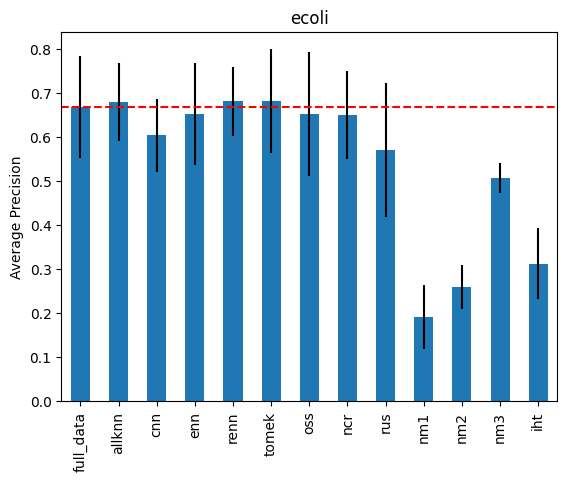

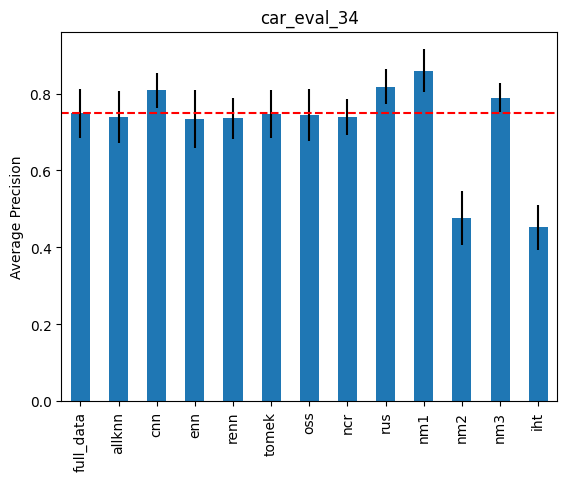

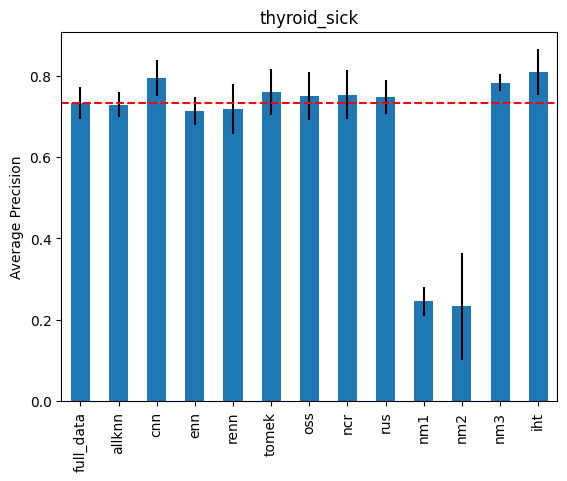

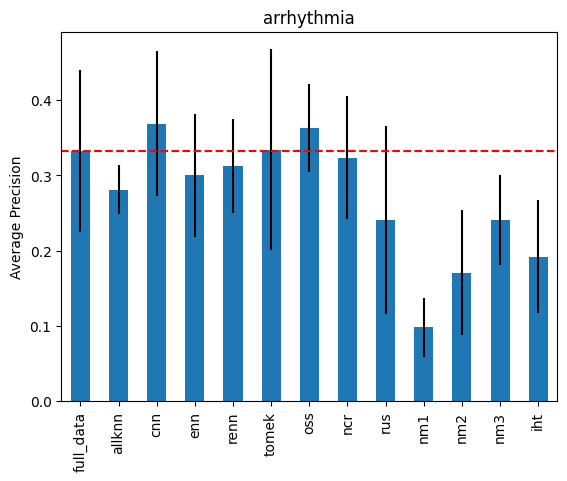

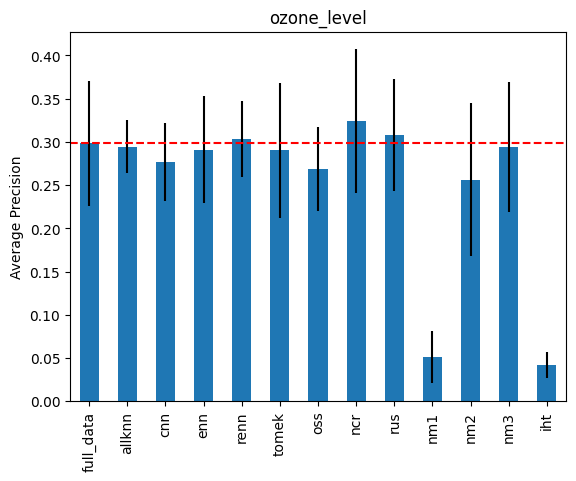

In [104]:
#Plotting the performance of the model that was not resampled

for dataset in datasets_ls:

    pr_mean_series = pd.Series(pr_mean_dict[dataset])
    pr_std_series = pd.Series(pr_std_dict[dataset])

    pr_mean_series.plot.bar(yerr=[pr_std_series, pr_std_series])
    plt.title(dataset)
    plt.ylabel('Average Precision')
    plt.axhline(pr_mean_dict[dataset]['full_data'], c='r', linestyle='--')
    plt.show()

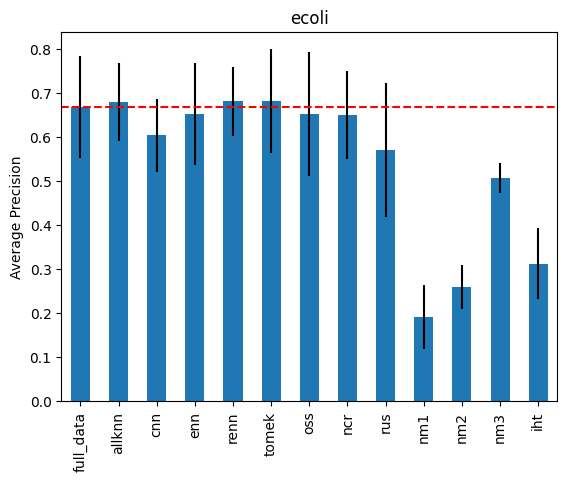

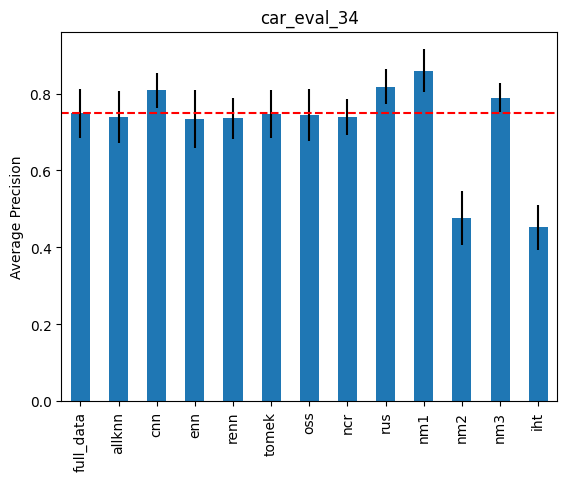

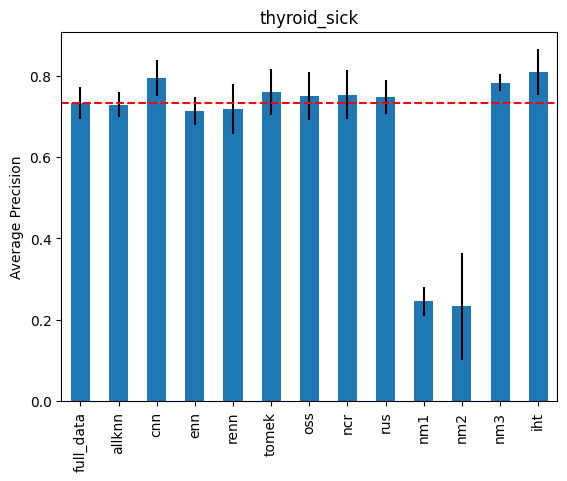

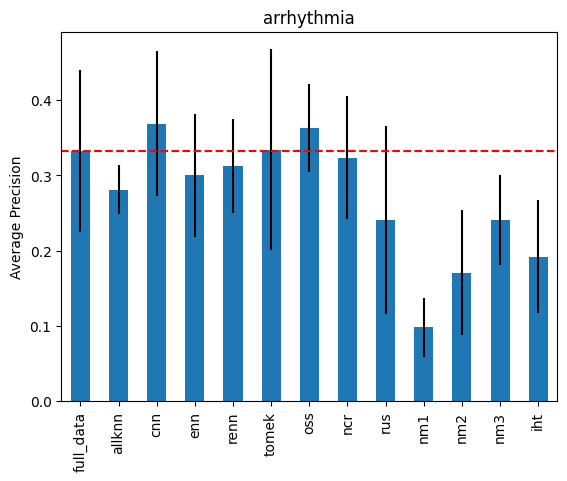

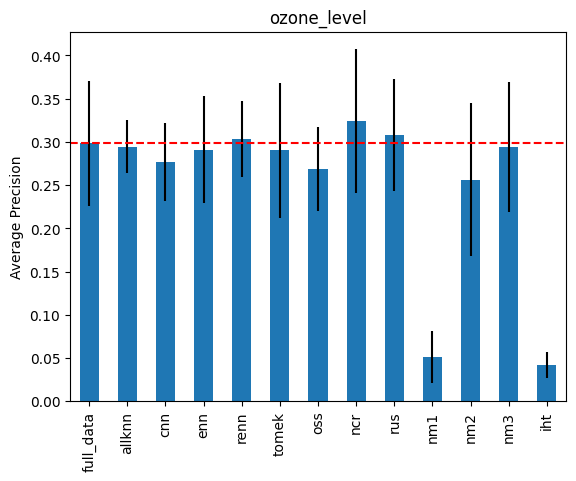

In [105]:
#Plotting the performance of the model that was not resampled

for dataset in datasets_ls:

    pr_mean_series = pd.Series(pr_mean_dict[dataset])
    pr_std_series = pd.Series(pr_std_dict[dataset])

    pr_mean_series.plot.bar(yerr=pr_std_series)
    plt.title(dataset)
    plt.ylabel('Average Precision')
    plt.axhline(pr_mean_dict[dataset]['full_data'], c='r', linestyle='--')
    plt.show()

In [54]:
?cross_validate

Signature:
cross_validate(
    estimator,
    X,
    y=None,
    *,
    groups=None,
    scoring=None,
    cv=None,
    n_jobs=None,
    verbose=0,
    params=None,
    pre_dispatch='2*n_jobs',
    return_train_score=False,
    return_estimator=False,
    return_indices=False,
    error_score=nan,
)
Docstring:
Evaluate metric(s) by cross-validation and also record fit/score times.

Read more in the :ref:`User Guide <multimetric_cross_validation>`.

Parameters
----------
estimator : estimator object implementing 'fit'
    The object to use to fit the data.

X : {array-like, sparse matrix} of shape (n_samples, n_features)
    The data to fit. Can be for example a list, or an array.

y : array-like of shape (n_samples,) or (n_samples, n_outputs), default=None
    The target variable to try to predict in the case of
    supervised learning.

groups : array-like of shape (n_samples,), default=None
    Group labels for the samples used while splitting the dataset into
    train/test set. Onl

In [50]:
test = 'anything'

not test

False

In [51]:
test = None
not test

True

In [59]:
data.data

array([[ 8.0000e-01,  1.8000e+00,  2.4000e+00, ...,  1.0330e+04,
        -5.5000e+01,  0.0000e+00],
       [ 2.8000e+00,  3.2000e+00,  3.3000e+00, ...,  1.0275e+04,
        -5.5000e+01,  0.0000e+00],
       [ 2.9000e+00,  2.8000e+00,  2.6000e+00, ...,  1.0235e+04,
        -4.0000e+01,  0.0000e+00],
       ...,
       [ 8.0000e-01,  8.0000e-01,  1.2000e+00, ...,  1.0275e+04,
        -3.5000e+01,  0.0000e+00],
       [ 1.3000e+00,  9.0000e-01,  1.5000e+00, ...,  1.0245e+04,
        -3.0000e+01,  5.0000e-02],
       [ 1.5000e+00,  1.3000e+00,  1.8000e+00, ...,  1.0220e+04,
        -2.5000e+01,  0.0000e+00]], shape=(2536, 72))

In [60]:
data.target

array([-1, -1, -1, ..., -1, -1, -1], shape=(2536,))

In [56]:
model = RandomForestClassifier()

In [61]:
X_train, X_test, y_train, y_test = train_test_split(data.data, data.target, test_size=0.3, random_state=0)

In [62]:
cv_results = cross_validate(
        estimator=model,
        X=X_train,
        y=y_train,
        scoring='average_precision',
        cv=3,
        n_jobs=-1,
    )

In [63]:
dir(cv_results)

['__class__',
 '__class_getitem__',
 '__contains__',
 '__delattr__',
 '__delitem__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__getitem__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__ior__',
 '__iter__',
 '__le__',
 '__len__',
 '__lt__',
 '__ne__',
 '__new__',
 '__or__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__reversed__',
 '__ror__',
 '__setattr__',
 '__setitem__',
 '__sizeof__',
 '__str__',
 '__subclasshook__',
 'clear',
 'copy',
 'fromkeys',
 'get',
 'items',
 'keys',
 'pop',
 'popitem',
 'setdefault',
 'update',
 'values']

In [64]:
cv_results.keys()

dict_keys(['fit_time', 'score_time', 'test_score'])

In [65]:
cv_results

{'fit_time': array([0.56253386, 0.58653927, 0.59858036]),
 'score_time': array([0.01903749, 0.02145076, 0.02311492]),
 'test_score': array([0.21752235, 0.22773248, 0.44008305])}

In [68]:
dir(cv_results['test_score'])

['T',
 '__abs__',
 '__add__',
 '__and__',
 '__array__',
 '__array_finalize__',
 '__array_function__',
 '__array_interface__',
 '__array_namespace__',
 '__array_priority__',
 '__array_struct__',
 '__array_ufunc__',
 '__array_wrap__',
 '__bool__',
 '__class__',
 '__class_getitem__',
 '__complex__',
 '__contains__',
 '__copy__',
 '__deepcopy__',
 '__delattr__',
 '__delitem__',
 '__dir__',
 '__divmod__',
 '__dlpack__',
 '__dlpack_device__',
 '__doc__',
 '__eq__',
 '__float__',
 '__floordiv__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__getitem__',
 '__gt__',
 '__hash__',
 '__iadd__',
 '__iand__',
 '__ifloordiv__',
 '__ilshift__',
 '__imatmul__',
 '__imod__',
 '__imul__',
 '__index__',
 '__init__',
 '__init_subclass__',
 '__int__',
 '__invert__',
 '__ior__',
 '__ipow__',
 '__irshift__',
 '__isub__',
 '__iter__',
 '__itruediv__',
 '__ixor__',
 '__le__',
 '__len__',
 '__lshift__',
 '__lt__',
 '__matmul__',
 '__mod__',
 '__mul__',
 '__ne__',
 '__neg__',
 '__new__',
 '__or__',
 '__pos__

In [72]:
cv_results['test_score']


array([0.21752235, 0.22773248, 0.44008305])

In [74]:
cv_results['test_score'].mean()


np.float64(0.295112627354902)

In [71]:
cv_results['test_auc']


KeyError: 'test_auc'

In [79]:
run_model(X_train, y_train)

Random Forests average precision: 0.29837510195324496 +/- 0.07219095034389267


(np.float64(0.29837510195324496), np.float64(0.07219095034389267))